In [46]:
import requests
import pandas as pd
import numpy as np
import plotly.express as px
import plotly.graph_objects as go

In [47]:
url = "https://services.swpc.noaa.gov/products/noaa-planetary-k-index.json"

response =  requests.get(url)

response.status_code

200

In [48]:
# the dates this dataset give is from June 14 to June 21 2026 later when You use this notebook for EDA 
# and all the dates will be A week back from current date

In [49]:
data = response.json()
type(data)

list

In [50]:
len(data)

60

In [51]:
# why just 59?
# Because Kp is reported every 3 hours

In [52]:
data[:5]

[{'time_tag': '2026-06-18T00:00:00',
  'Kp': 2.0,
  'a_running': 7,
  'station_count': 7},
 {'time_tag': '2026-06-18T03:00:00',
  'Kp': 1.67,
  'a_running': 6,
  'station_count': 7},
 {'time_tag': '2026-06-18T06:00:00',
  'Kp': 0.67,
  'a_running': 3,
  'station_count': 7},
 {'time_tag': '2026-06-18T09:00:00',
  'Kp': 1.33,
  'a_running': 5,
  'station_count': 7},
 {'time_tag': '2026-06-18T12:00:00',
  'Kp': 1.0,
  'a_running': 4,
  'station_count': 7}]

In [53]:
df = pd.DataFrame(data)

df.tail()

,time_tag,Kp,a_running,station_count
55,2026-06-24T21:00:00,4.00,27,8
56,2026-06-25T00:00:00,4.33,32,8
57,2026-06-25T03:00:00,5.00,48,8
58,2026-06-25T06:00:00,3.67,22,8
59,2026-06-25T09:00:00,2.67,12,8


| Kp | Meaning        |
| -- | -------------- |
| 0  | Very Quiet     |
| 1  | Quiet          |
| 2  | Quiet          |
| 3  | Unsettled      |
| 4  | Active         |
| 5  | Minor Storm    |
| 6  | Moderate Storm |
| 7  | Strong Storm   |
| 8  | Severe Storm   |
| 9  | Extreme Storm  |


In [46]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 59 entries, 0 to 58
Data columns (total 4 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   time_tag       59 non-null     str    
 1   Kp             59 non-null     float64
 2   a_running      59 non-null     int64  
 3   station_count  59 non-null     int64  
dtypes: float64(1), int64(2), str(1)
memory usage: 2.0 KB


In [47]:
df.describe()

,Kp,a_running,station_count
count,59.000000,59.000000,59.000000
mean,1.587627,6.203390,7.864407
std,0.650444,2.790252,0.345295
min,0.330000,2.000000,7.000000
25%,1.000000,4.000000,8.000000
50%,1.670000,6.000000,8.000000
75%,2.000000,7.000000,8.000000
max,3.000000,15.000000,8.000000


In [48]:
df["time_tag"] = pd.to_datetime(df["time_tag"])

In [49]:
df.loc[df["Kp"].idxmax()]

time_tag         2026-06-19 00:00:00
Kp                               3.0
a_running                         15
station_count                      8
Name: 16, dtype: object

In [50]:
df.loc[df["Kp"].idxmin()]

time_tag         2026-06-17 18:00:00
Kp                              0.33
a_running                          2
station_count                      8
Name: 6, dtype: object

In [51]:
# Negative Bz
# ≠
# Guaranteed Storm

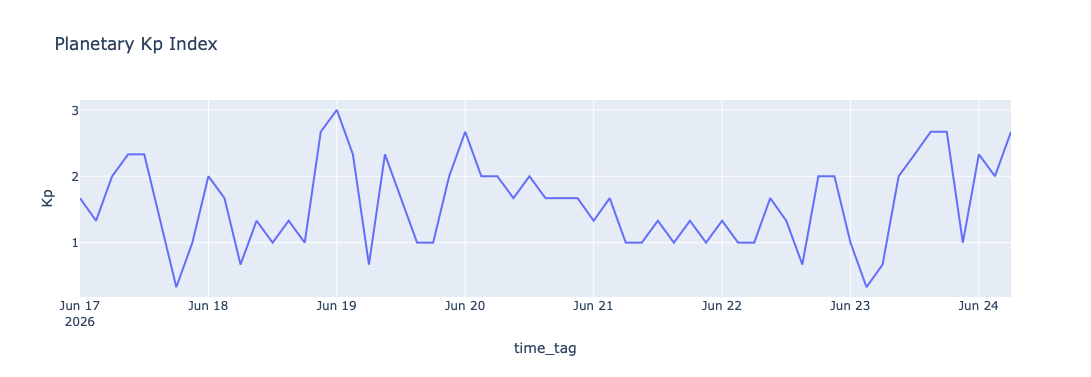

In [52]:
fig = px.line(
    df,
    x="time_tag",
    y="Kp",
    title="Planetary Kp Index"
)

fig

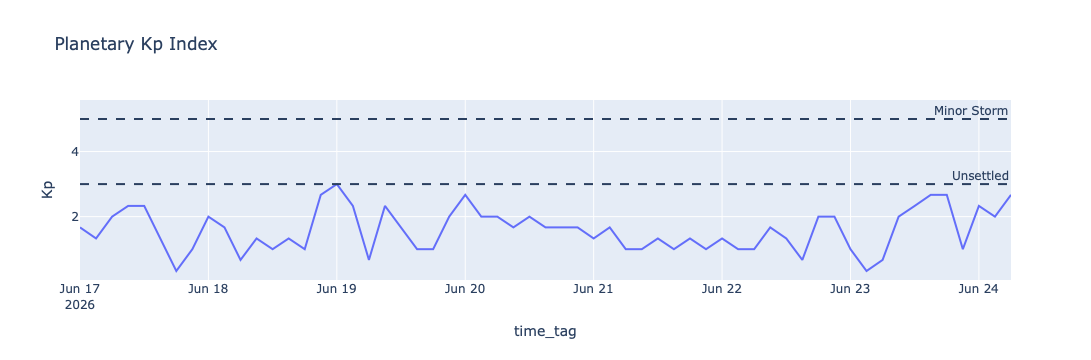

In [53]:
fig = px.line(
    df,
    x="time_tag",
    y="Kp",
    title="Planetary Kp Index"
)

fig.add_hline(y=3,
              line_dash="dash",
              annotation_text="Unsettled")

fig.add_hline(y=5,
              line_dash="dash",
              annotation_text="Minor Storm")

fig

In [54]:
df[df["Kp"] >=2.33]

,time_tag,Kp,a_running,station_count
3,2026-06-17 09:00:00,2.33,9,8
4,2026-06-17 12:00:00,2.33,9,8
15,2026-06-18 21:00:00,2.67,12,8
16,2026-06-19 00:00:00,3.00,15,8
17,2026-06-19 03:00:00,2.33,9,8
19,2026-06-19 09:00:00,2.33,9,8
24,2026-06-20 00:00:00,2.67,12,8
52,2026-06-23 12:00:00,2.33,9,8
53,2026-06-23 15:00:00,2.67,12,8
54,2026-06-23 18:00:00,2.67,12,7


In [56]:
solar_url = "https://services.swpc.noaa.gov/products/solar-wind/plasma-7-day.json"

solar_data = requests.get(solar_url).json()

solar_df = pd.DataFrame(
    solar_data[1:],
    columns=solar_data[0]
)

solar_df.head()

,time_tag,density,speed,temperature
0,2026-06-17 09:28:00.000,4.83,438.1,134354
1,2026-06-17 09:29:00.000,7.44,445.7,187698
2,2026-06-17 09:30:00.000,7.04,447.3,181462
3,2026-06-17 09:31:00.000,7.30,451.6,224175
4,2026-06-17 09:32:00.000,5.94,456.7,219713


In [57]:
imf_url = "https://services.swpc.noaa.gov/products/solar-wind/mag-7-day.json"

imf_data = requests.get(imf_url).json()

imf_df = pd.DataFrame(
    imf_data[1:],
    columns=imf_data[0]
)

imf_df.head()

,time_tag,bx_gsm,by_gsm,bz_gsm,lon_gsm,lat_gsm,bt
0,2026-06-17 09:28:00.000,3.97,4.24,-0.26,46.90,-2.58,5.82
1,2026-06-17 09:29:00.000,3.90,4.38,-0.30,48.27,-2.90,5.91
2,2026-06-17 09:30:00.000,4.11,4.27,-0.33,46.06,-3.19,5.95
3,2026-06-17 09:31:00.000,4.15,4.21,-0.03,45.39,-0.30,5.93
4,2026-06-17 09:32:00.000,4.27,3.91,0.46,42.47,4.56,5.81


In [58]:
solar_df["time_tag"] = pd.to_datetime(solar_df["time_tag"])

for col in ["density", "speed", "temperature"]:
    solar_df[col] = pd.to_numeric(solar_df[col])

In [59]:
imf_df["time_tag"] = pd.to_datetime(imf_df["time_tag"])

for col in [
    "bx_gsm",
    "by_gsm",
    "bz_gsm",
    "bt",
    "lon_gsm",
    "lat_gsm"
]:
    imf_df[col] = pd.to_numeric(imf_df[col])

In [60]:
kp_df = df.copy()

In [61]:
sw_imf = pd.merge(
    solar_df,
    imf_df,
    on="time_tag",
    how="inner"
)

In [62]:
sw_imf.shape

(9874, 10)

In [63]:
sw_imf["kp_time"] = sw_imf["time_tag"].dt.floor("3h")

In [64]:
sw_imf_3h = (
    sw_imf
    .groupby("kp_time")
    .agg({
        "density": "mean",
        "speed": "mean",
        "temperature": "mean",
        "bz_gsm": "mean",
        "bt": "mean"
    })
    .reset_index()
)

In [65]:
sw_imf_3h.rename(
    columns={"kp_time": "time_tag"},
    inplace=True
)

In [66]:
kp_merged = pd.merge(
    kp_df,
    sw_imf_3h,
    on="time_tag",
    how="inner"
)

In [67]:
kp_merged.head()

,time_tag,Kp,a_running,station_count,density,speed,temperature,bz_gsm,bt
0,2026-06-17 09:00:00,2.33,9,8,6.250662,455.701471,185925.992647,-3.274559,5.378529
1,2026-06-17 12:00:00,2.33,9,8,6.778696,472.607826,215951.800000,-1.314957,4.182783
2,2026-06-17 15:00:00,1.33,5,8,4.630667,467.071111,151122.800000,0.162056,3.342611
3,2026-06-17 18:00:00,0.33,2,8,4.853056,465.584444,141919.844444,-0.010222,2.947500
4,2026-06-17 21:00:00,1.00,4,8,6.150944,455.618333,160223.872222,-0.581111,2.649944


In [68]:
kp_merged.corr(numeric_only=True)

,Kp,a_running,station_count,density,speed,temperature,bz_gsm,bt
Kp,1.000000,0.963897,0.077256,0.480419,0.145780,0.121658,-0.339434,0.408569
a_running,0.963897,1.000000,0.066907,0.516108,0.132099,0.104347,-0.334086,0.398944
station_count,0.077256,0.066907,1.000000,-0.184552,-0.121432,0.112136,0.117679,0.276459
density,0.480419,0.516108,-0.184552,1.000000,0.212357,0.137570,-0.238604,0.402654
speed,0.145780,0.132099,-0.121432,0.212357,1.000000,0.831421,-0.036314,0.030298
temperature,0.121658,0.104347,0.112136,0.137570,0.831421,1.000000,0.049003,0.142452
bz_gsm,-0.339434,-0.334086,0.117679,-0.238604,-0.036314,0.049003,1.000000,0.181702
bt,0.408569,0.398944,0.276459,0.402654,0.030298,0.142452,0.181702,1.000000


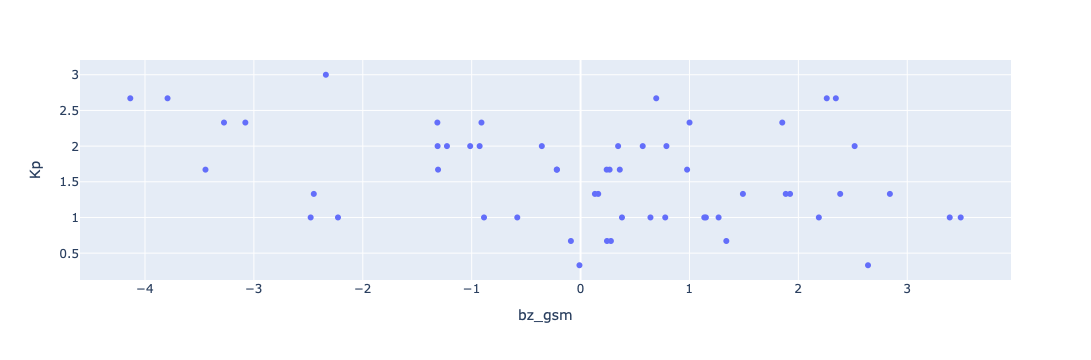

In [69]:
px.scatter(
    kp_merged,
    x="bz_gsm",
    y="Kp"
)

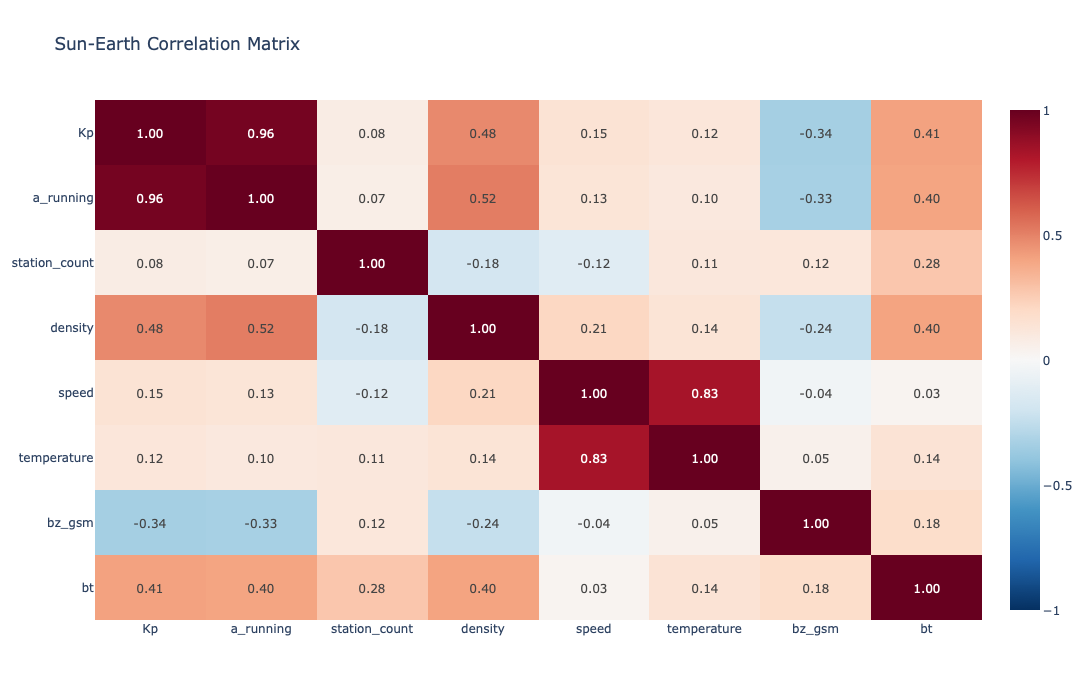

In [70]:


corr_matrix = kp_merged.corr(numeric_only=True)

fig = px.imshow(
    corr_matrix,
    text_auto=".2f",
    color_continuous_scale="RdBu_r",
    zmin=-1,
    zmax=1,
    aspect="auto",
    title="Sun-Earth Correlation Matrix"
)

fig.update_layout(
    width=900,
    height=700
)

fig.show()